# Tarea Semanal 12 - Teoria de Circuitos 2

## Profesor: Mariano Llamedo Soria
## Jefe de TPs: César Fuoco

## Alumno: Ignacio Gomez Pugliese

## Parte A

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<class 'sympy.core.mul.Mul'>
s**2*(1.0*s**4 + 1.499999999972*s**2 + 0.562499999984128)
<class 'dict'>
{-1.3077484661862e-6 - 0.866025403777342*I: 1, -1.3077484661862e-6 + 0.866025403777342*I: 1, 1.3077484661862e-6 - 0.866025403777342*I: 1, 1.3077484661862e-6 + 0.866025403777342*I: 1, 0: 2}


...

#### 3º Remoción en $\infty$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Se descartarán los coeficientes poco significativos

<IPython.core.display.Math object>

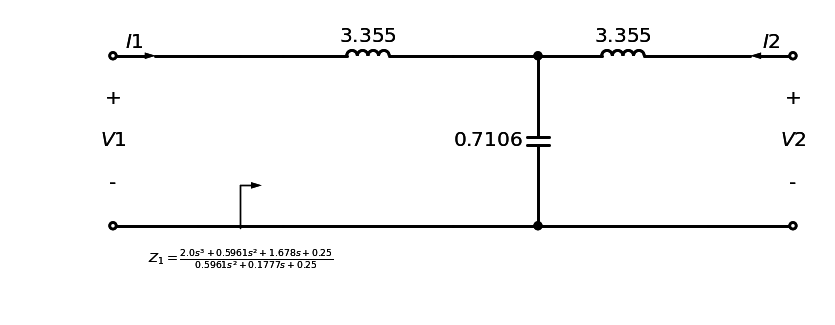

In [2]:
import sympy as sp
from scipy import signal
import numpy as np

# Ahora importamos las funciones de PyTC2

from pytc2.remociones import remover_polo_dc, remover_polo_infinito, modsq2mod_s, trim_func_s

from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s
from IPython.display import display,  Markdown

# Importante importar símbolos de variables 
from pytc2.general import s, w, simplify_n_monic

from pytc2.dibujar import dibujar_puerto_entrada, dibujar_puerto_salida, dibujar_elemento_serie, dibujar_elemento_derivacion, dibujar_tanque_serie, dibujar_funcion_exc_abajo, dibujar_espacio_derivacion
from schemdraw import Drawing

c = 1/4
a=0.596071638
b=0.9276506988

T2proto = c/(s**3+a*s**2+b*s+c)

S21 = T2proto

ks21, Ps, Es = simplify_n_monic(S21)

S21 = ks21 * Ps / Es

print_latex(a_equal_b_latex_s('S_{21}', S21))

print_latex(a_equal_b_latex_s('S_{21}(\omega = 1)', sp.simplify(sp.expand(sp.Abs(S21.subs(s, sp.I*1)))).evalf(4) ))

S21sq = sp.simplify(sp.expand(S21 * S21.subs(s, -s)))

S11sq = sp.simplify(sp.expand(1 - S21sq))

print_latex(a_equal_b_latex_s('S_{21sq}', S21sq))

print_latex(a_equal_b_latex_s('S_{11sq}', S11sq))

S11_sign = 1

S11 = S11_sign * modsq2mod_s(S11sq, bTryNumeric=True)

print_latex(a_equal_b_latex_s('S_{11sq}', S11))

Z1 = sp.simplify(sp.expand(1 + S11) / sp.expand(1 - S11))

print_latex(a_equal_b_latex_s('Z_{1}', Z1))

print_subtitle('1º Remoción en $\infty$')

Z2, ZL1 = remover_polo_infinito(Z1)

# ZL1 es la impedancia removida
# extraigo L1
L1 = ZL1/s

print_latex(a_equal_b_latex_s('L_1', L1.evalf(4)))
print_latex(a_equal_b_latex_s('Z_2', Z2.evalf(4)))

print_subtitle('Se descartarán los coeficientes poco significativos')

Z2 = trim_func_s(Z2)
print_latex(a_equal_b_latex_s('Z_2', Z2.evalf(4)))

print_subtitle('2º Remoción en $\infty$')

Y3, YC1 = remover_polo_infinito(1/Z2)

# YC1 es la impedancia removida
# extraigo C1
C1 = YC1/s

print_latex(a_equal_b_latex_s('C_1', C1.evalf(4)))
print_latex(a_equal_b_latex_s('Y_3', Y3.evalf(4)))

print_subtitle('Se descartarán los coeficientes poco significativos')

Y3 = trim_func_s(Y3)
print_latex(a_equal_b_latex_s('Y_3', Z2.evalf(4)))

print_subtitle('3º Remoción en $\infty$')

Z4, ZL2 = remover_polo_infinito(1/Y3)

# YC1 es la impedancia removida
# extraigo C1
L2 = ZL2/s

print_latex(a_equal_b_latex_s('L_2', L2.evalf(4)))
print_latex(a_equal_b_latex_s('Z_4', Z4.evalf(4)))

print_subtitle('Se descartarán los coeficientes poco significativos')

Z4 = trim_func_s(Z4)
print_latex(a_equal_b_latex_s('Z_4', Z4.evalf(4)))

d = dibujar_puerto_entrada( Drawing(unit=4),
                        voltage_lbl = ('+', '$V1$', '-'), 
                        current_lbl = '$I1$')

d = dibujar_funcion_exc_abajo(d, 'Z_1',  
                                  Z1.evalf(4), 
                                  hacia_salida = True,
                                  k_gap_width = 0.5)

d = dibujar_elemento_serie(d, 'L', L1.evalf(4))

d = dibujar_espacio_derivacion(d)

d = dibujar_elemento_derivacion(d, 'C', C1.evalf(4))

d = dibujar_elemento_serie(d, 'L', L2.evalf(4))

d = dibujar_puerto_salida(d,
                          voltage_lbl = ('+', '$V2$', '-'), 
                          current_lbl = '$I2$')


display(d)

## Parte B

### 1

La función principal de un VNA (Vector Network Analyzer) es medir cómo una red eléctrica responde ante señales de distintas frecuencias. Para ello utiliza los llamados parámetros S (scattering parameters), que describen la relación entre las ondas incidentes y reflejadas en los puertos del dispositivo bajo prueba.

* Entre las mediciones más comunes que realiza un VNA se encuentran:
* Coeficiente de reflexión (S11).
* Transmisión (S21).
* Impedancia compleja.
* ROE (SWR).
* Pérdidas por inserción y pérdidas de retorno.
* Fase y retardo de grupo.

El NanoVNA es una versión compacta y de bajo costo de un VNA, muy utilizada en entornos educativos y de laboratorio para mediciones de RF.

### 2

A continuación se comparan ambos instrumentos considerando algunas características clave.

Ancho de Banda

NanoVNA:
Dependiendo del modelo, el NanoVNA puede cubrir aproximadamente desde decenas de kHz hasta 3 GHz o más, lo cual lo hace adecuado para aplicaciones de RF y microondas.

Osciloscopio DSO GW Instek:
Los osciloscopios típicos de GW Instek tienen anchos de banda del orden de 70 MHz a 200 MHz, aunque existen modelos superiores. Están pensados para observar señales en el dominio del tiempo, no para caracterización en RF.

Conclusión: el VNA trabaja en un rango de frecuencias mucho mayor.

Rango Dinámico

NanoVNA:
Posee un rango dinámico del orden de 60 a 90 dB, dependiendo de la frecuencia y de la calibración. Esto permite detectar variaciones pequeñas en la respuesta del dispositivo.

Osciloscopio GW Instek:
El concepto de rango dinámico no se expresa de la misma forma que en un VNA. Está más relacionado con la resolución vertical y la sensibilidad de entrada, y no está optimizado para mediciones de atenuación o reflexión en RF.

Conclusión: el VNA tiene un rango dinámico específicamente diseñado para mediciones de parámetros S.

Impedancia de Entrada

NanoVNA:
Está diseñado para sistemas RF con impedancia característica de 50 Ω, que es el estándar en líneas de transmisión y antenas.

Osciloscopio GW Instek:
Normalmente presenta una impedancia de entrada de 1 MΩ (con una capacitancia asociada), aunque algunos modelos permiten seleccionar 50 Ω.

Conclusión: el VNA trabaja directamente en entornos de 50 Ω, mientras que el osciloscopio prioriza no cargar el circuito bajo medición.

### 3

Aunque el NanoVNA es un instrumento que opera principalmente en el dominio de la frecuencia, también permite obtener información relacionada con el dominio del tiempo.
A través del procesamiento matemático de los datos de frecuencia, es posible realizar mediciones tipo TDR (Time Domain Reflectometry).

Este tipo de medición permite:
* Estimar la longitud de cables.
* Detectar discontinuidades de impedancia.
* Localizar fallas o empalmes en líneas de transmisión.
  
Cabe aclarar que esta medición no es equivalente a la visualización directa de señales en el tiempo que ofrece un osciloscopio, sino que se obtiene mediante transformaciones a partir de los datos en frecuencia.